# Diffusion Inpainting Augmentation — Final Checkpoint Preparation

This notebook prepares the final checkpoint folder for the three-model assignment comparison.

Models prepared:
1. Baseline CNN
2. Traditional Augmentation CNN
3. Diffusion Inpainting Augmentation CNN

Design decisions:
- Uses the selected best pretrained denoiser checkpoint (`denoiser_student_final_epoch1050.keras`) as the diffusion generator.
- Saves only final checkpoints for the classifier models.
- Trains classifiers for one fixed full schedule and saves the final epoch checkpoint.
- Validation and test sets are never augmented or modified.
- Diffusion-generated samples are added only to the training set.
- Generated X-rays are only for educational augmentation experiments.

In [1]:
import os, json, sys, shutil, random
import numpy as np
import tensorflow as tf
import keras
from keras import layers
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image as IPyImage, display
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("Visible GPUs:", tf.config.list_physical_devices("GPU"))
print("Python:", sys.version)

2026-05-19 12:12:50.262250: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.20.0
Keras: 3.12.1
Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Python: 3.10.8 | packaged by conda-forge | (main, Nov 22 2022, 08:23:14) [GCC 10.4.0]


In [2]:
# ── Reproducibility ──
SEED = 42

def reset_all_seeds(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    try:
        keras.utils.set_random_seed(seed)
    except Exception:
        pass

reset_all_seeds(SEED)

# ── Core constants ──
IMG_SIZE = 64
BATCH_SIZE = 32
CLASSIFIER_EPOCHS = 25

MINORITY_CLASS = 1                 # Pneumonia, verified against MedMNIST INFO below
MINORITY_KEEP_FRACTION = 0.20      # Artificially keep 20% of pneumonia samples in train
TARGET_MINORITY_MULTIPLIER = 2     # Generate enough samples to double current minority count

DIFFUSION_TIMESTEPS = 50
NOISE_BETA_START = 1e-4
NOISE_BETA_END = 0.02
INPAINT_MASK_FRAC = 0.25

# ── Checkpoint paths ──
CHECKPOINT_DIR = "checkpoints"
VIZ_DIR = os.path.join(CHECKPOINT_DIR, "visualizations")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(VIZ_DIR, exist_ok=True)

BEST_DENOISER_EPOCH = 1050
BEST_DENOISER_PATH = os.path.join(CHECKPOINT_DIR, f"denoiser_student_final_epoch{BEST_DENOISER_EPOCH}.keras")
DENOISER_FINAL_PATH = os.path.join(CHECKPOINT_DIR, "denoiser_final.keras")

BASELINE_FINAL_PATH = os.path.join(CHECKPOINT_DIR, "baseline_cnn_final.keras")
TRAD_AUG_FINAL_PATH = os.path.join(CHECKPOINT_DIR, "traditional_aug_cnn_final.keras")
DIFFUSION_AUG_FINAL_PATH = os.path.join(CHECKPOINT_DIR, "diffusion_aug_cnn_final.keras")

METADATA_PATH = os.path.join(CHECKPOINT_DIR, "checkpoint_metadata.json")
EXPECTED_METRICS_PATH = os.path.join(CHECKPOINT_DIR, "expected_metrics.json")

print("Checkpoint directory:", os.path.abspath(CHECKPOINT_DIR))
print("Selected best denoiser source:", BEST_DENOISER_PATH)
print("Classifier epochs:", CLASSIFIER_EPOCHS)

Checkpoint directory: /home/jshresth/RL_deeplearning/artificial-intelligence/Diffusion Inpainting Augmentation/checkpoints
Selected best denoiser source: checkpoints/denoiser_student_final_epoch1050.keras
Classifier epochs: 25


## Data Loading

Load PneumoniaMNIST at 64×64 if supported by the installed MedMNIST version. If not, load the default image size and resize to 64×64. Labels are flattened to 1D integer arrays.

In [3]:
from medmnist import PneumoniaMNIST, INFO

info = INFO["pneumoniamnist"]
label_map = info["label"]
print("Label mapping:", label_map)
assert label_map[str(MINORITY_CLASS)] == "pneumonia", "MINORITY_CLASS must correspond to pneumonia."

splits = {}
for split_name in ["train", "val", "test"]:
    try:
        ds = PneumoniaMNIST(split=split_name, download=True, size=IMG_SIZE)
        images = ds.imgs.astype(np.float32) / 255.0
        if images.ndim == 3:
            images = images[..., np.newaxis]
        print(f"{split_name}: loaded at size={IMG_SIZE}")
    except Exception as e:
        print(f"{split_name}: size={IMG_SIZE} load failed ({e}); resizing default images instead.")
        ds = PneumoniaMNIST(split=split_name, download=True)
        images = ds.imgs.astype(np.float32) / 255.0
        if images.ndim == 3:
            images = images[..., np.newaxis]
        images = tf.image.resize(images, [IMG_SIZE, IMG_SIZE]).numpy().astype(np.float32)

    labels = ds.labels.squeeze().astype(np.int32)
    splits[split_name] = (images.astype(np.float32), labels)
    print(f"  shape={images.shape}, counts={np.bincount(labels, minlength=2)}")

train_images, train_labels = splits["train"]
val_images, val_labels = splits["val"]
test_images, test_labels = splits["test"]
train_counts_before = np.bincount(train_labels, minlength=2)

Label mapping: {'0': 'normal', '1': 'pneumonia'}
Using downloaded and verified file: /home/jshresth/.medmnist/pneumoniamnist_64.npz
train: loaded at size=64
  shape=(4708, 64, 64, 1), counts=[1214 3494]
Using downloaded and verified file: /home/jshresth/.medmnist/pneumoniamnist_64.npz
val: loaded at size=64
  shape=(524, 64, 64, 1), counts=[135 389]
Using downloaded and verified file: /home/jshresth/.medmnist/pneumoniamnist_64.npz
test: loaded at size=64
  shape=(624, 64, 64, 1), counts=[234 390]


## Helper Functions

In [4]:
# ── Plotting ──
def plot_class_distribution(labels, title="Class Distribution", save_name=None):
    counts = np.bincount(labels.astype(np.int32), minlength=2)
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(["normal (0)", "pneumonia (1)"], counts)
    for i, v in enumerate(counts):
        ax.text(i, v + max(5, counts.max() * 0.01), str(v), ha="center", fontweight="bold")
    ax.set_title(title)
    ax.set_ylabel("Count")
    plt.tight_layout()
    if save_name:
        path = os.path.join(VIZ_DIR, save_name)
        plt.savefig(path, dpi=200, bbox_inches="tight")
        plt.close(fig)
        print(f"Saved: {path}")
        display(IPyImage(filename=path))
    else:
        plt.show()


def plot_image_grid(images, n=8, title="Images", save_name=None):
    n = min(n, len(images))
    cols = min(n, 8)
    rows = max(1, (n + cols - 1) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.5))
    axes = np.array(axes).reshape(-1)
    for i in range(n):
        img = images[i].numpy().squeeze() if hasattr(images[i], "numpy") else np.squeeze(images[i])
        axes[i].imshow(img, cmap="gray")
        axes[i].axis("off")
    for i in range(n, len(axes)):
        axes[i].axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    if save_name:
        path = os.path.join(VIZ_DIR, save_name)
        plt.savefig(path, dpi=200, bbox_inches="tight")
        plt.close(fig)
        print(f"Saved: {path}")
        display(IPyImage(filename=path))
    else:
        plt.show()


def plot_confusion_matrix(cm, model_name="Model", save_name=None):
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["normal", "pneumonia"])
    ax.set_yticklabels(["normal", "pneumonia"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(model_name)
    threshold = cm.max() / 2 if cm.size and cm.max() > 0 else 0
    for i in range(2):
        for j in range(2):
            ax.text(
                j, i, str(cm[i][j]), ha="center", va="center",
                color="white" if cm[i][j] > threshold else "black", fontsize=14
            )
    plt.tight_layout()
    if save_name:
        path = os.path.join(VIZ_DIR, save_name)
        plt.savefig(path, dpi=200, bbox_inches="tight")
        plt.close(fig)
        print(f"Saved: {path}")
        display(IPyImage(filename=path))
    else:
        plt.show()


# ── tf.data ──
def make_tf_dataset(images, labels, batch_size=BATCH_SIZE, shuffle=True, augment_fn=None):
    images = images.astype(np.float32)
    labels = labels.astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((images, labels))
    if shuffle:
        ds = ds.shuffle(len(images), seed=SEED, reshuffle_each_iteration=True)
    if augment_fn is not None:
        ds = ds.map(lambda x, y: (augment_fn(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


# ── Imbalance ──
def create_imbalance(images, labels, minority_class=MINORITY_CLASS, keep_fraction=MINORITY_KEEP_FRACTION, seed=SEED):
    rng = np.random.RandomState(seed)
    minority_mask = labels == minority_class
    majority_mask = ~minority_mask
    minority_images = images[minority_mask]
    minority_labels = labels[minority_mask]
    n_keep = int(len(minority_images) * keep_fraction)
    selected = rng.choice(len(minority_images), n_keep, replace=False)
    out_images = np.concatenate([images[majority_mask], minority_images[selected]], axis=0)
    out_labels = np.concatenate([labels[majority_mask], minority_labels[selected]], axis=0)
    perm = rng.permutation(len(out_images))
    return out_images[perm].astype(np.float32), out_labels[perm].astype(np.int32)


# ── CNN ──
def build_cnn(img_size=IMG_SIZE):
    model = keras.Sequential([
        layers.Input(shape=(img_size, img_size, 1)),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(1, activation="sigmoid"),
    ], name="pneumonia_cnn")
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


# ── Realistic traditional augmentation ──
TRAD_ROTATION_FACTOR = 0.025
TRAD_TRANSLATION_FACTOR = 0.040
TRAD_ZOOM_FACTOR = 0.050
TRAD_CONTRAST_FACTOR = 0.10
TRAD_FILL_MODE = "nearest"

def build_augmentation_pipeline():
    return keras.Sequential([
        layers.RandomRotation(TRAD_ROTATION_FACTOR, fill_mode=TRAD_FILL_MODE, seed=SEED),
        layers.RandomTranslation(TRAD_TRANSLATION_FACTOR, TRAD_TRANSLATION_FACTOR,
                                 fill_mode=TRAD_FILL_MODE, seed=SEED),
        layers.RandomZoom(TRAD_ZOOM_FACTOR, fill_mode=TRAD_FILL_MODE, seed=SEED),
        layers.RandomContrast(TRAD_CONTRAST_FACTOR, seed=SEED),
    ], name="traditional_augmentation")


# ── Evaluation ──
def evaluate_model(model, images, labels, model_name="Model"):
    preds_prob = model.predict(images.astype(np.float32), verbose=0).squeeze()
    preds = (preds_prob >= 0.5).astype(np.int32)
    labels = labels.astype(np.int32)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    prec = precision_score(labels, preds, pos_label=MINORITY_CLASS, zero_division=0)
    rec = recall_score(labels, preds, pos_label=MINORITY_CLASS, zero_division=0)
    cm = confusion_matrix(labels, preds, labels=[0, 1])
    print(f"\n{'=' * 50}\n  {model_name} — Test Evaluation\n{'=' * 50}")
    print(f"  Accuracy: {acc:.4f}  Macro-F1: {f1:.4f}")
    print(f"  Minority Precision: {prec:.4f}  Minority Recall: {rec:.4f}")
    print(classification_report(labels, preds, target_names=["normal", "pneumonia"], zero_division=0))
    return {
        "accuracy": float(acc),
        "macro_f1": float(f1),
        "minority_precision": float(prec),
        "minority_recall": float(rec),
        "confusion_matrix": cm.tolist(),
    }


# ── Checkpoint validation ──
def validate_checkpoint(path, is_denoiser=False):
    assert os.path.exists(path), f"Missing checkpoint: {path}"
    tmp = keras.saving.load_model(path)
    print(f"  ✓ Loaded {path}")
    if is_denoiser:
        d_img = np.random.rand(2, IMG_SIZE, IMG_SIZE, 1).astype(np.float32)
        d_t = np.array([0, 1], dtype=np.int32)
        noise = np.random.normal(size=d_img.shape).astype(np.float32)
        noisy = q_sample(d_img, d_t, noise)
        pred = tmp.predict([noisy, d_t], verbose=0)
        assert pred.shape == (2, IMG_SIZE, IMG_SIZE, 1)
        assert np.all(np.isfinite(pred))
        tmp.compile(optimizer="adam", loss="mse")
        tmp.fit([noisy, d_t], noise, epochs=1, verbose=0)
    else:
        d = np.random.rand(2, IMG_SIZE, IMG_SIZE, 1).astype(np.float32)
        pred = tmp.predict(d, verbose=0)
        assert pred.shape == (2, 1)
        assert np.all(np.isfinite(pred))
        assert np.all((pred >= 0) & (pred <= 1))
        tmp.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
        tmp.fit(d, np.array([0, 1], dtype=np.float32), epochs=1, verbose=0)
    print(f"  ✓ Validated {path}")
    del tmp


def train_classifier_fixed(model, train_ds, val_ds, final_path, model_name, seed_offset=0):
    """Train for the full fixed schedule and save the final checkpoint.

    Validation is monitored during training for visibility only; final evaluation is computed
    once on the unchanged test set.
    """
    reset_all_seeds(SEED + seed_offset)
    print(f"\n── Training {model_name} for {CLASSIFIER_EPOCHS} epochs ──")
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=CLASSIFIER_EPOCHS,
        verbose=1,
    )
    model.save(final_path)
    print(f"Saved final checkpoint: {final_path}")
    validate_checkpoint(final_path)
    return model, history

## Diffusion Schedule & Denoiser Architecture

The denoiser architecture is defined so Keras can reload the selected `.keras` checkpoint. This notebook does **not** train the denoiser from scratch.

In [5]:
# ── Linear beta schedule ──
betas_np = np.linspace(NOISE_BETA_START, NOISE_BETA_END, DIFFUSION_TIMESTEPS, dtype=np.float32)
alphas_np = 1.0 - betas_np
alpha_bars_np = np.cumprod(alphas_np).astype(np.float32)
BETAS = tf.constant(betas_np)
ALPHAS = tf.constant(alphas_np)
ALPHA_BARS = tf.constant(alpha_bars_np)


def q_sample(x0, t, noise=None):
    x0 = tf.cast(x0, tf.float32)
    if noise is None:
        noise = tf.random.normal(tf.shape(x0))
    t = tf.cast(t, tf.int32)
    ab = tf.gather(ALPHA_BARS, t)
    while len(ab.shape) < len(x0.shape):
        ab = ab[..., tf.newaxis]
    return tf.sqrt(ab) * x0 + tf.sqrt(1.0 - ab) * noise


@keras.saving.register_keras_serializable(package="DiffusionInpainting")
class SinusoidalTimeEmbedding(layers.Layer):
    def __init__(self, dim=64, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim

    def call(self, t):
        half = self.dim // 2
        freqs = tf.exp(-tf.math.log(10000.0) * tf.range(half, dtype=tf.float32) / half)
        t_f = tf.cast(tf.reshape(t, [-1]), tf.float32)
        args = t_f[:, tf.newaxis] * freqs[tf.newaxis, :]
        return tf.concat([tf.sin(args), tf.cos(args)], axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({"dim": self.dim})
        return config


def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("swish")(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("swish")(x)
    return x


def build_denoiser(img_size=IMG_SIZE, t_emb_dim=64):
    img_in = layers.Input(shape=(img_size, img_size, 1), name="noisy_image")
    t_in = layers.Input(shape=(), dtype=tf.int32, name="timestep")

    t_emb = SinusoidalTimeEmbedding(dim=t_emb_dim)(t_in)
    t_emb = layers.Dense(t_emb_dim, activation="swish")(t_emb)
    t_emb = layers.Dense(t_emb_dim, activation="swish")(t_emb)

    def add_time(x, t_emb):
        t_proj = layers.Dense(x.shape[-1])(t_emb)
        t_proj = layers.Reshape((1, 1, x.shape[-1]))(t_proj)
        return x + t_proj

    filters_list = [64, 128, 256]
    skips = []
    x = img_in
    for f in filters_list:
        x = conv_block(x, f)
        x = add_time(x, t_emb)
        skips.append(x)
        x = layers.Conv2D(f, 3, strides=2, padding="same")(x)

    x = conv_block(x, 512)
    x = add_time(x, t_emb)

    for f in reversed(filters_list):
        x = layers.Conv2DTranspose(f, 3, strides=2, padding="same")(x)
        x = layers.Concatenate()([x, skips.pop()])
        x = conv_block(x, f)
        x = add_time(x, t_emb)

    out = layers.Conv2D(1, 3, padding="same")(x)
    return keras.Model(inputs=[img_in, t_in], outputs=out, name="denoiser")


def reverse_step(model, x_t, t):
    n = tf.shape(x_t)[0]
    t_batch = tf.fill([n], t)
    pred_noise = model([x_t, t_batch], training=False)
    alpha = ALPHAS[t]
    alpha_bar = ALPHA_BARS[t]
    beta = BETAS[t]
    mean = (1.0 / tf.sqrt(alpha)) * (x_t - (beta / tf.sqrt(1.0 - alpha_bar)) * pred_noise)
    if t > 0:
        return mean + tf.sqrt(beta) * tf.random.normal(tf.shape(x_t))
    return mean


def generate_inpainted_samples(model, source_images, n_per_image=1, mask_frac=INPAINT_MASK_FRAC):
    results = []
    for src in source_images:
        src = tf.cast(src, tf.float32)
        if len(src.shape) == 2:
            src = src[..., tf.newaxis]
        for _ in range(n_per_image):
            h = w = IMG_SIZE
            mh = int(h * mask_frac)
            mw = int(w * mask_frac)
            top = np.random.randint(0, h - mh + 1)
            left = np.random.randint(0, w - mw + 1)
            mask = np.zeros((h, w, 1), dtype=np.float32)
            mask[top:top + mh, left:left + mw, :] = 1.0
            mask_tf = tf.constant(mask)
            x = tf.random.normal((1, IMG_SIZE, IMG_SIZE, 1))
            src_b = src[tf.newaxis]
            for t in reversed(range(DIFFUSION_TIMESTEPS)):
                x = reverse_step(model, x, t)
                if t > 0:
                    noised_src = q_sample(src_b, tf.constant([t]))
                    x = mask_tf * x + (1.0 - mask_tf) * noised_src
                else:
                    x = mask_tf * x + (1.0 - mask_tf) * src_b
            results.append(tf.clip_by_value(x[0], 0.0, 1.0))
    return tf.stack(results)


def generate_inpainted_with_fixed_mask(model, source_image, mask):
    src = tf.cast(source_image, tf.float32)
    if len(src.shape) == 2:
        src = src[..., tf.newaxis]
    src_b = src[tf.newaxis]
    mask_tf = tf.constant(mask.astype(np.float32))
    x = tf.random.normal((1, IMG_SIZE, IMG_SIZE, 1))
    for t in reversed(range(DIFFUSION_TIMESTEPS)):
        x = reverse_step(model, x, t)
        if t > 0:
            noised_src = q_sample(src_b, tf.constant([t]))
            x = mask_tf * x + (1.0 - mask_tf) * noised_src
        else:
            x = mask_tf * x + (1.0 - mask_tf) * src_b
    return tf.clip_by_value(x[0], 0.0, 1.0)


def make_soft_mask(mask, blur_size=5):
    mask_tf = tf.convert_to_tensor(mask[tf.newaxis], dtype=tf.float32)
    for _ in range(2):
        mask_tf = tf.nn.avg_pool2d(mask_tf, ksize=blur_size, strides=1, padding="SAME")
    return tf.clip_by_value(mask_tf[0], 0.0, 1.0).numpy()


def save_fixed_mask_inpainting_visualization(denoiser, source_images, n=6, mask_frac=INPAINT_MASK_FRAC, seed=SEED, save_name="final_denoiser_fixed_mask_visualization.png"):
    rng = np.random.default_rng(seed)
    n = min(n, len(source_images))
    h = w = IMG_SIZE
    mh = int(h * mask_frac)
    mw = int(w * mask_frac)
    fig, axes = plt.subplots(n, 3, figsize=(6, n * 2))
    if n == 1:
        axes = axes[np.newaxis, :]
    for i in range(n):
        src = source_images[i]
        src_2d = np.squeeze(src)
        top = rng.integers(0, h - mh + 1)
        left = rng.integers(0, w - mw + 1)
        mask = np.zeros((h, w, 1), dtype=np.float32)
        mask[top:top + mh, left:left + mw, :] = 1.0
        masked_vis = src_2d.copy()
        masked_vis[top:top + mh, left:left + mw] = 0.5
        raw_inpainted = generate_inpainted_with_fixed_mask(denoiser, src, mask)
        soft_mask = make_soft_mask(mask)
        display_inpainted = soft_mask * raw_inpainted.numpy() + (1.0 - soft_mask) * src
        display_inpainted = np.clip(display_inpainted, 0.0, 1.0)
        axes[i, 0].imshow(src_2d, cmap="gray")
        axes[i, 0].axis("off")
        axes[i, 1].imshow(masked_vis, cmap="gray")
        axes[i, 1].axis("off")
        axes[i, 2].imshow(np.squeeze(display_inpainted), cmap="gray")
        axes[i, 2].axis("off")
    axes[0, 0].set_title("Original", fontsize=9)
    axes[0, 1].set_title("Same Mask", fontsize=9)
    axes[0, 2].set_title("Inpainted", fontsize=9)
    fig.suptitle("Diffusion Inpainting Visualization — Same Mask + Display-Only Soft Blend")
    plt.tight_layout()
    path = os.path.join(VIZ_DIR, save_name)
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {path}")
    display(IPyImage(filename=path))

I0000 00:00:1779210775.577870 2856440 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79196 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:01:00.0, compute capability: 8.0
I0000 00:00:1779210775.579269 2856440 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 78667 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:25:00.0, compute capability: 8.0


## Create Artificial Imbalance

Applied **only to the training split**. Validation and test sets remain untouched.

Saved: checkpoints/visualizations/train_before_imbalance.png


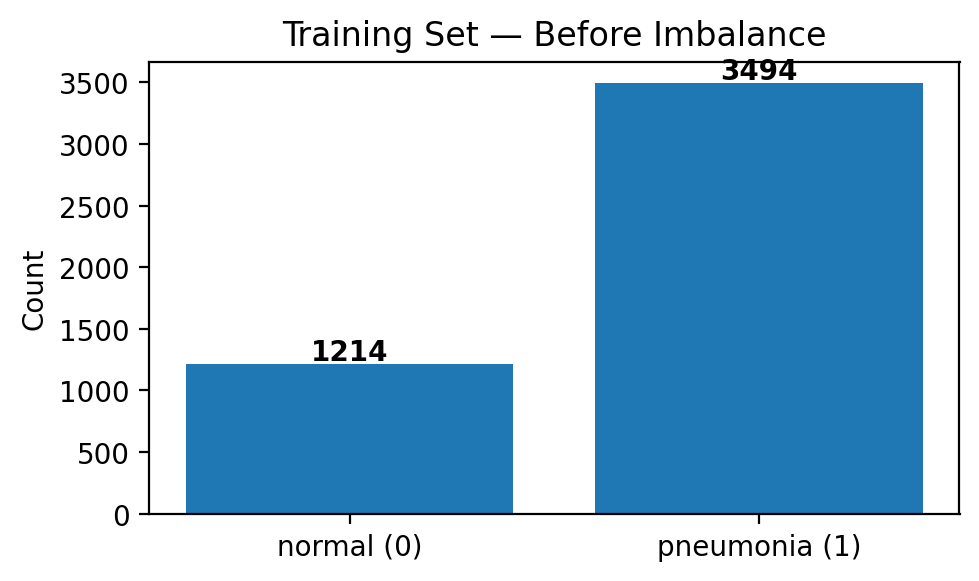

Saved: checkpoints/visualizations/train_after_imbalance.png


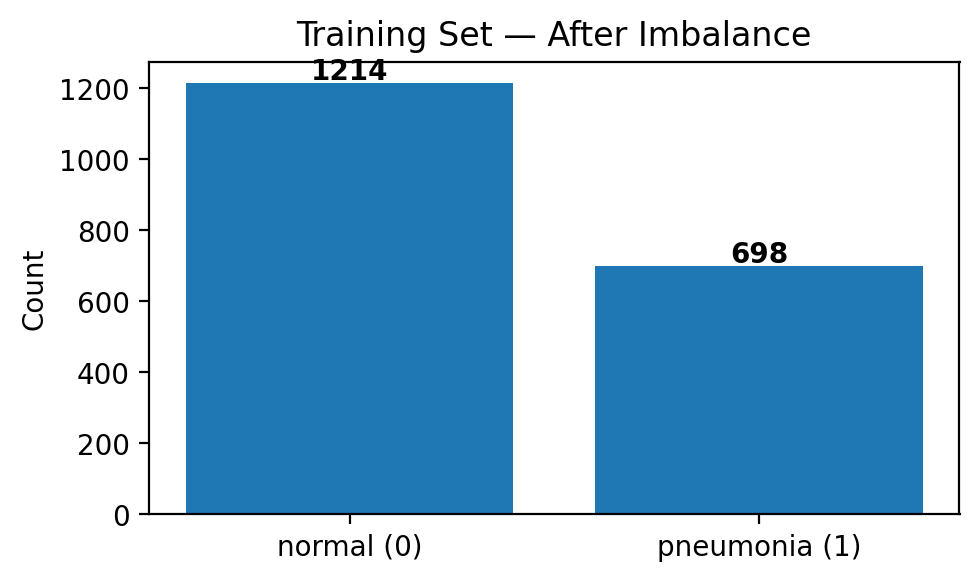

Kept 698 of 3494 pneumonia samples


In [6]:
plot_class_distribution(train_labels, "Training Set — Before Imbalance", save_name="train_before_imbalance.png")
imb_train_images, imb_train_labels = create_imbalance(train_images, train_labels)
train_counts_after = np.bincount(imb_train_labels, minlength=2)
plot_class_distribution(imb_train_labels, "Training Set — After Imbalance", save_name="train_after_imbalance.png")
print(f"Kept {train_counts_after[MINORITY_CLASS]} of {train_counts_before[MINORITY_CLASS]} pneumonia samples")

## Load Selected Best Denoiser

This notebook does **not** retrain the denoiser from scratch. It expects the selected best checkpoint `denoiser_student_final_epoch1050.keras` to already exist in `checkpoints/`.

The checkpoint is copied to `denoiser_final.keras` and loaded into the active `denoiser` variable used for visualization and diffusion sample generation.

In [7]:
minority_mask = imb_train_labels == MINORITY_CLASS
minority_images = imb_train_images[minority_mask]
print(f"Minority samples available for denoiser-based generation: {len(minority_images)}")

if not os.path.exists(BEST_DENOISER_PATH):
    raise FileNotFoundError(
        f"Missing best denoiser checkpoint: {BEST_DENOISER_PATH}\n"
        "Place denoiser_student_final_epoch1050.keras inside checkpoints/ before running this notebook."
    )

shutil.copy2(BEST_DENOISER_PATH, DENOISER_FINAL_PATH)
print(f"Promoted {BEST_DENOISER_PATH} -> {DENOISER_FINAL_PATH}")

denoiser = keras.saving.load_model(DENOISER_FINAL_PATH)
validate_checkpoint(DENOISER_FINAL_PATH, is_denoiser=True)

Minority samples available for denoiser-based generation: 698
Promoted checkpoints/denoiser_student_final_epoch1050.keras -> checkpoints/denoiser_final.keras
  ✓ Loaded checkpoints/denoiser_final.keras


2026-05-19 12:13:01.917724: I external/local_xla/xla/service/service.cc:163] XLA service 0x70d5a80036c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-19 12:13:01.917757: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2026-05-19 12:13:01.917764: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (1): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2026-05-19 12:13:01.966054: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-19 12:13:02.104687: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
I0000 00:00:1779210784.141247 2857227 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  ✓ Validated checkpoints/denoiser_final.keras


### Denoiser Visualization

The same binary mask is used for the masked panel and generated output. A soft mask is applied only for display blending; generated training images are not soft-blended.

Saved: checkpoints/visualizations/final_denoiser_fixed_mask_visualization.png


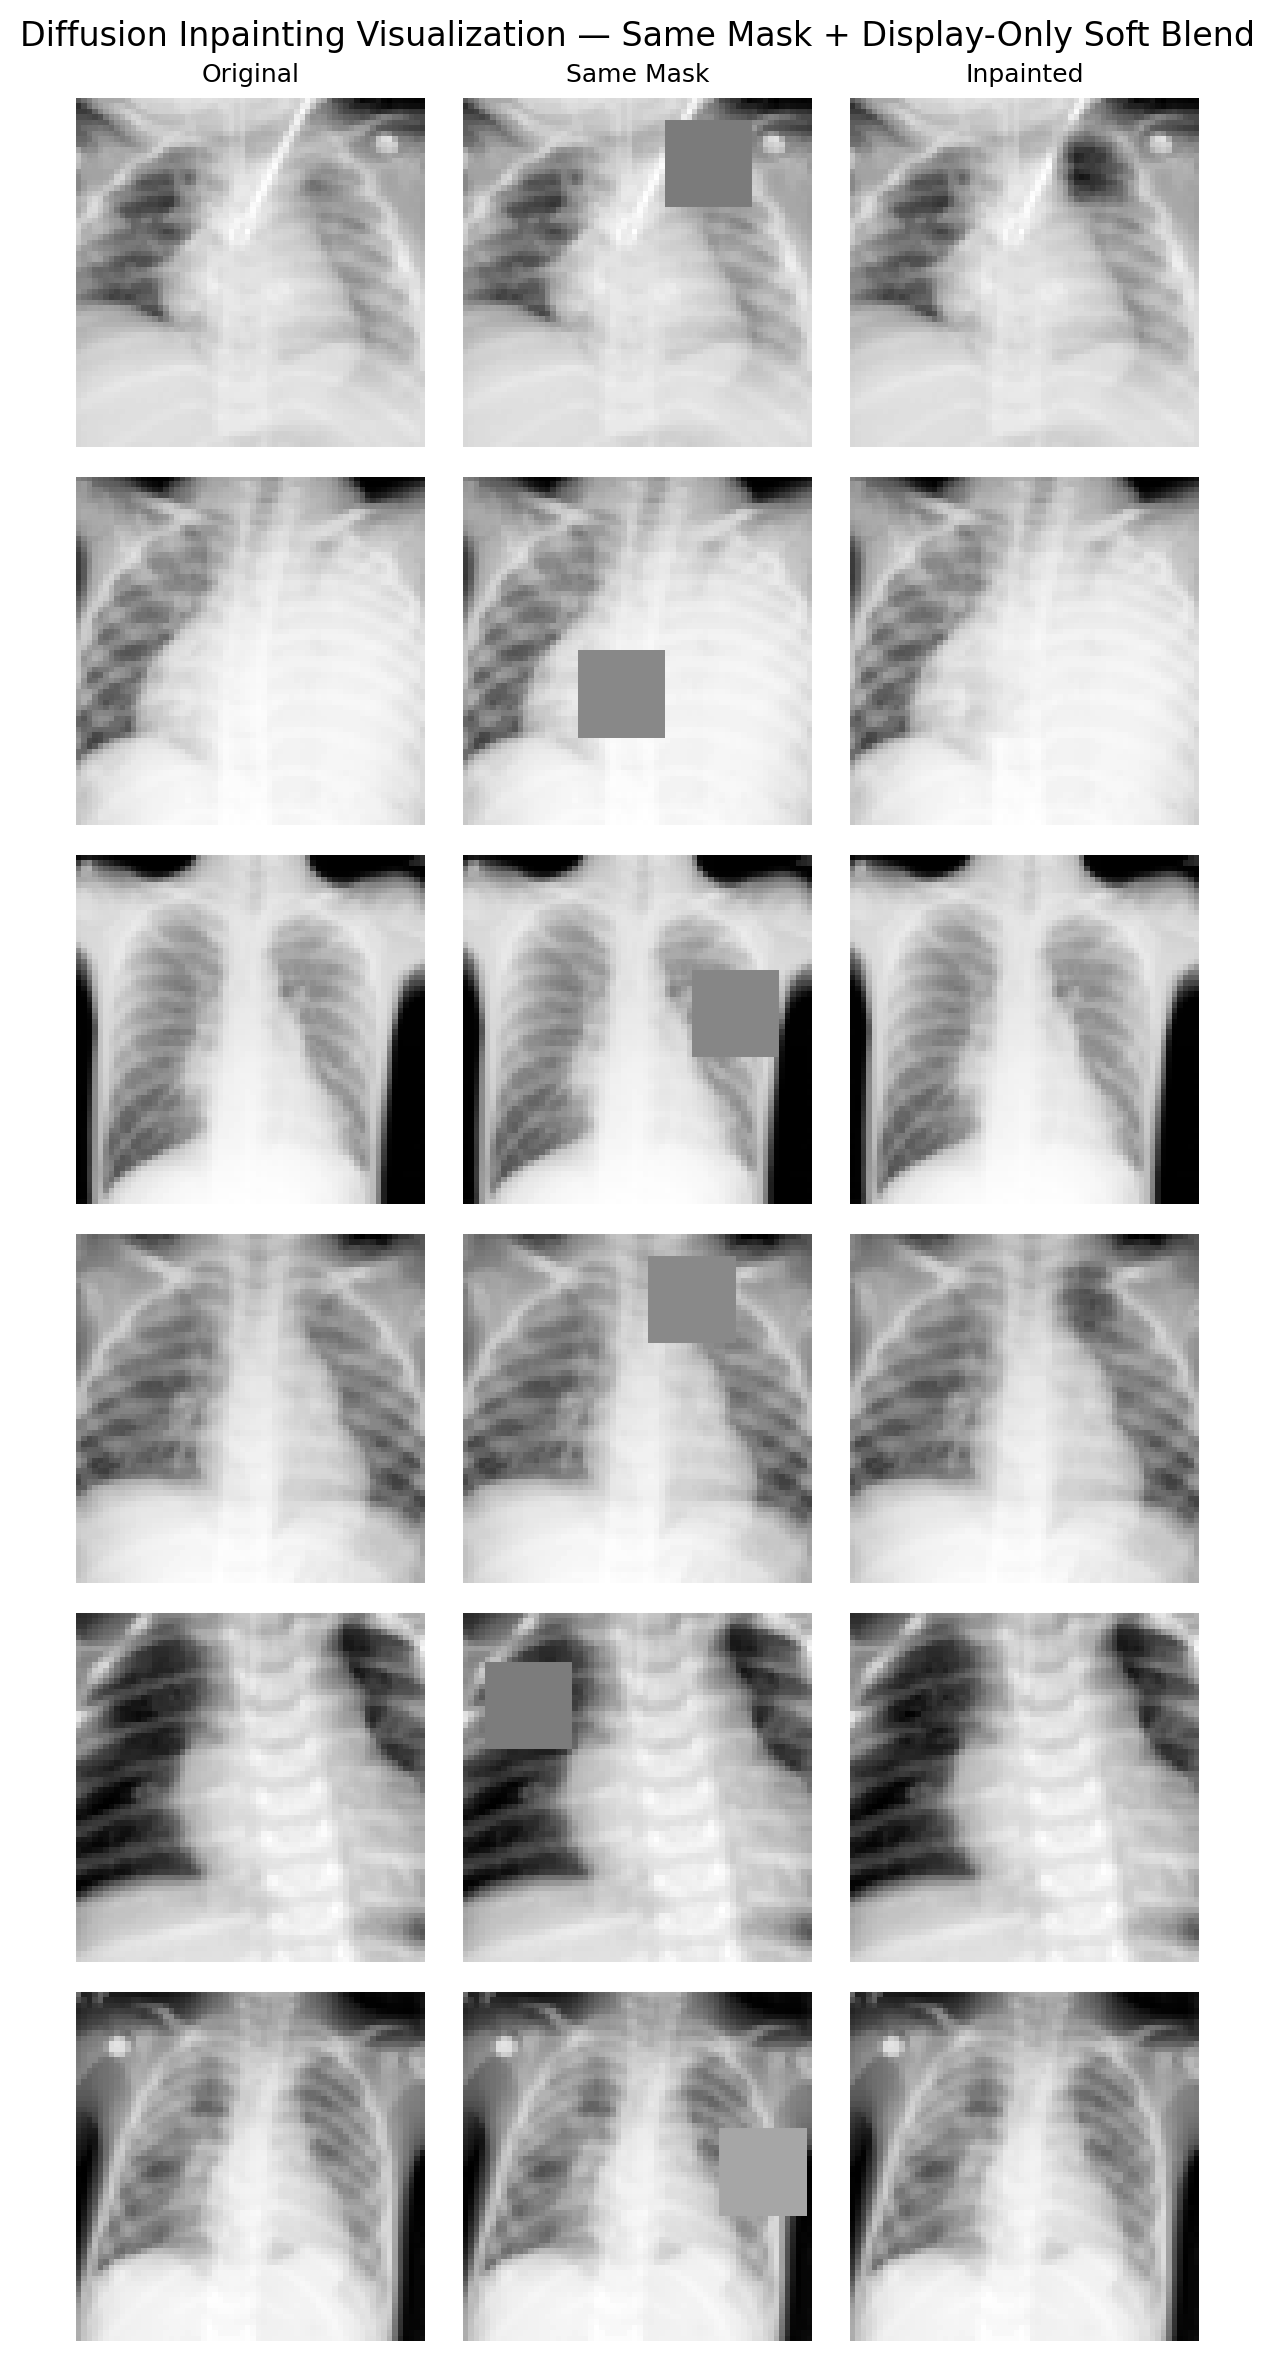

Saved: checkpoints/visualizations/original_minority_samples.png


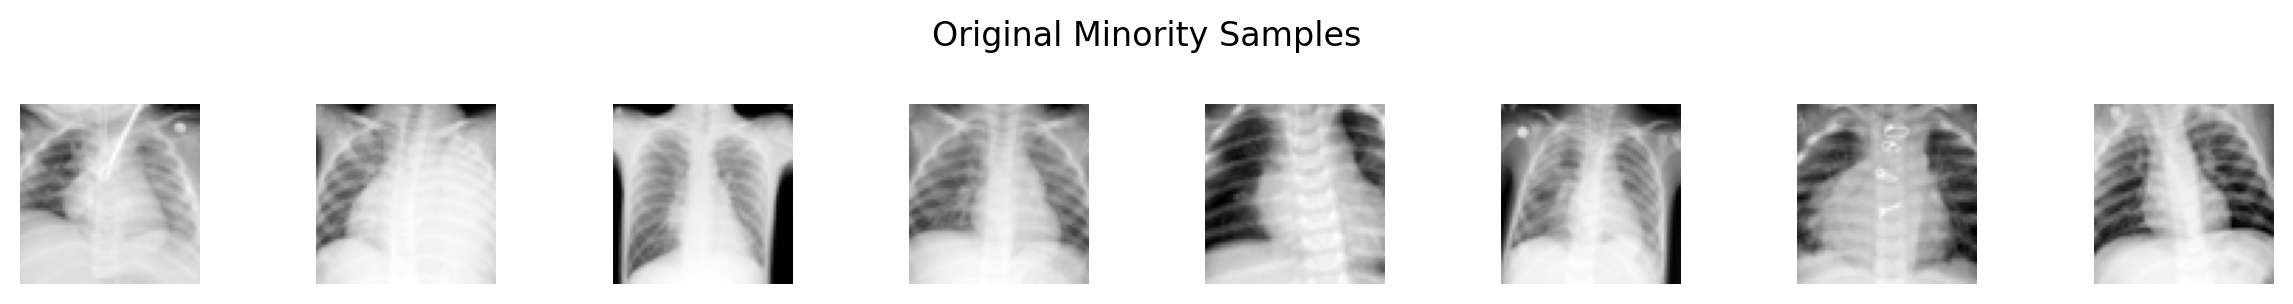

Saved: checkpoints/visualizations/generated_minority_quick_check.png


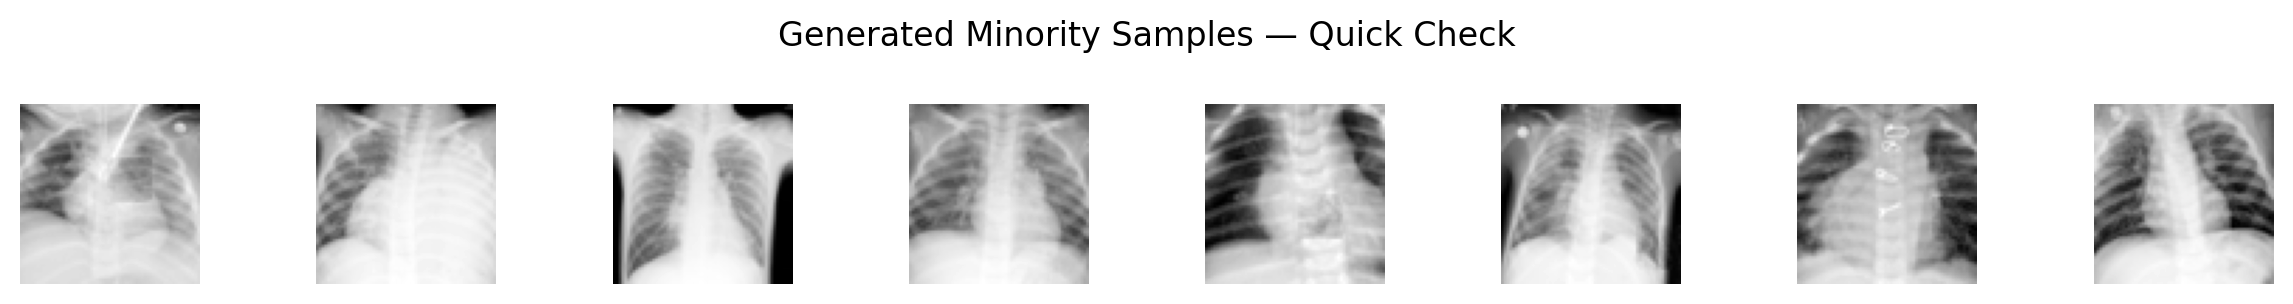

In [8]:
save_fixed_mask_inpainting_visualization(
    denoiser,
    minority_images[:6],
    n=6,
    mask_frac=INPAINT_MASK_FRAC,
    seed=SEED,
    save_name="final_denoiser_fixed_mask_visualization.png",
)

quick_recon = generate_inpainted_samples(denoiser, minority_images[:8], n_per_image=1, mask_frac=INPAINT_MASK_FRAC)
plot_image_grid(minority_images[:8], n=8, title="Original Minority Samples", save_name="original_minority_samples.png")
plot_image_grid(quick_recon, n=8, title="Generated Minority Samples — Quick Check", save_name="generated_minority_quick_check.png")

## Train Baseline CNN

The baseline model trains only on the artificially imbalanced training set.


── Training Baseline CNN for 25 epochs ──
Epoch 1/25


2026-05-19 12:14:03.272335: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-19 12:14:03.272367: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-19 12:14:03.272377: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-19 12:14:03.597725: I external/l

58/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8609 - loss: 0.2800

2026-05-19 12:14:07.355821: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-19 12:14:07.355853: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-19 12:14:07.800264: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1244', 8 bytes spill stores, 8 bytes spill loads

2026-05-19 12:14:07.952938: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : R

60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - accuracy: 0.9079 - loss: 0.2228 - val_accuracy: 0.7424 - val_loss: 2.0868
Epoch 2/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9467 - loss: 0.1482 - val_accuracy: 0.7424 - val_loss: 4.1572
Epoch 3/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9582 - loss: 0.1149 - val_accuracy: 0.7424 - val_loss: 5.2038
Epoch 4/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9561 - loss: 0.1265 - val_accuracy: 0.7424 - val_loss: 5.6495
Epoch 5/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9754 - loss: 0.0708 - val_accuracy: 0.7424 - val_loss: 8.0093
Epoch 6/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9686 - loss: 0.0793 - val_accuracy: 0.7424 - val_loss: 5.3788
Epoch 7/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9786 - loss: 0.0541 - val_accuracy: 0.7424 - val_loss: 4.7199
Epoch 8/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9796 - loss: 0.0644 - val_accuracy: 0.7481 - val_loss: 2.1308
E

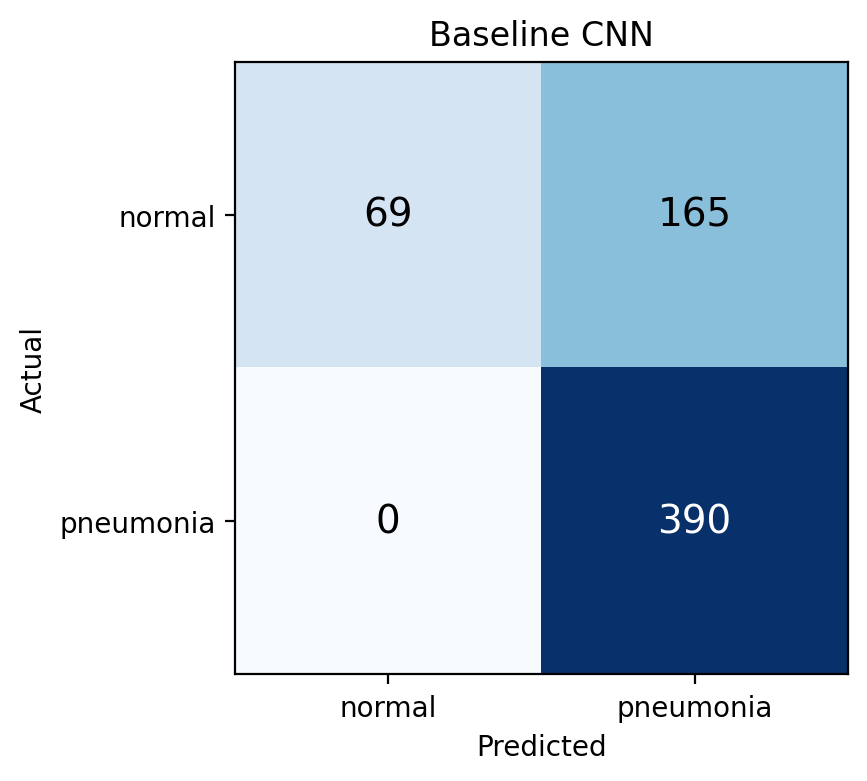

In [9]:
reset_all_seeds(SEED + 1000)

baseline_train_ds = make_tf_dataset(imb_train_images, imb_train_labels)
val_ds = make_tf_dataset(val_images, val_labels, shuffle=False)

baseline_cnn = build_cnn()
baseline_cnn, baseline_history = train_classifier_fixed(
    baseline_cnn,
    baseline_train_ds,
    val_ds,
    BASELINE_FINAL_PATH,
    "Baseline CNN",
    seed_offset=1000,
)

baseline_metrics = evaluate_model(baseline_cnn, test_images, test_labels, "Baseline CNN")
plot_confusion_matrix(np.array(baseline_metrics["confusion_matrix"]), "Baseline CNN", save_name="baseline_confusion_matrix.png")

## Train Traditional Augmentation CNN

Traditional augmentation is applied only inside the training pipeline. Validation and test data remain unaugmented.


── Training Traditional Aug CNN for 25 epochs ──
Epoch 1/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - accuracy: 0.8959 - loss: 0.2646 - val_accuracy: 0.7424 - val_loss: 2.0672
Epoch 2/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9226 - loss: 0.1972 - val_accuracy: 0.7424 - val_loss: 3.7061
Epoch 3/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9393 - loss: 0.1617 - val_accuracy: 0.7424 - val_loss: 3.1135
Epoch 4/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9467 - loss: 0.1480 - val_accuracy: 0.7424 - val_loss: 3.2059
Epoch 5/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9487 - loss: 0.1320 - val_accuracy: 0.7424 - val_loss: 2.4542
Epoch 6/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9425 - loss: 0.1415 - val_accuracy: 0.7424 - val_loss: 2.3255
Epoch 7/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9566 - loss: 0.1129 - val_accuracy: 0.7424 - val_loss: 2.3422
Epoch 8/25
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy

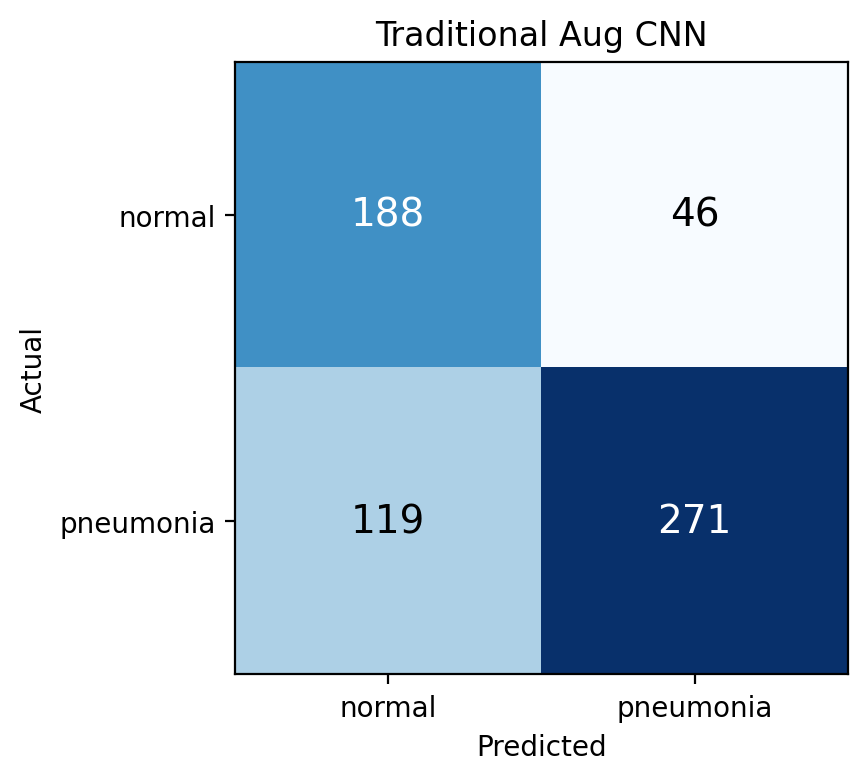

Saved: checkpoints/visualizations/traditional_augmented_samples.png


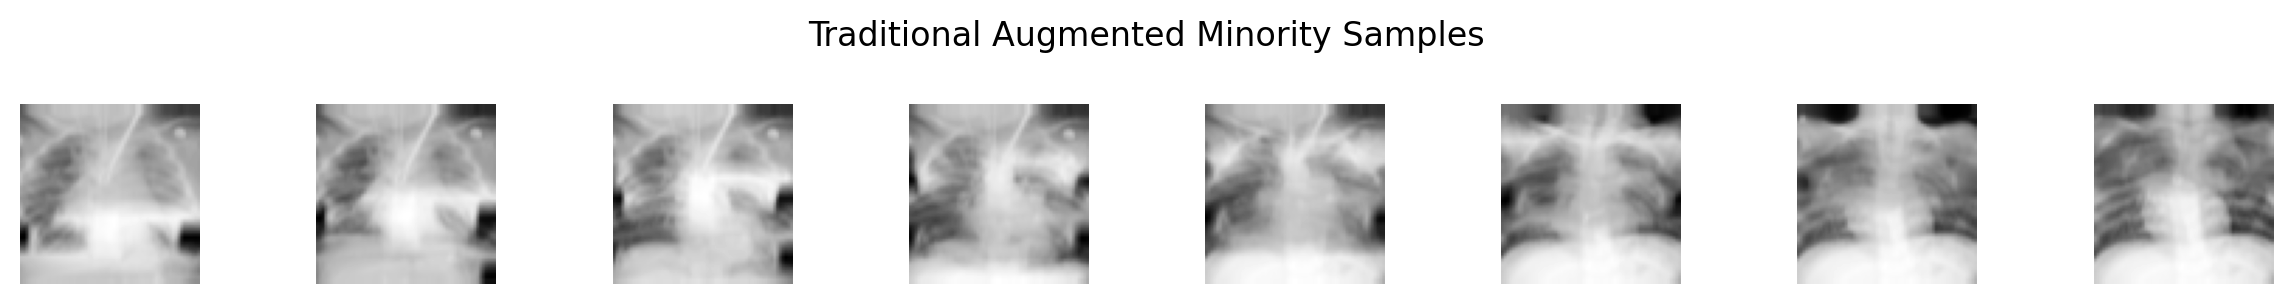

In [12]:
reset_all_seeds(SEED + 2000)

trad_aug_pipeline = build_augmentation_pipeline()
trad_train_ds = make_tf_dataset(imb_train_images, imb_train_labels, augment_fn=trad_aug_pipeline)

trad_aug_cnn = build_cnn()
trad_aug_cnn, trad_history = train_classifier_fixed(
    trad_aug_cnn,
    trad_train_ds,
    val_ds,
    TRAD_AUG_FINAL_PATH,
    "Traditional Aug CNN",
    seed_offset=2000,
)

trad_metrics = evaluate_model(trad_aug_cnn, test_images, test_labels, "Traditional Aug CNN")
plot_confusion_matrix(np.array(trad_metrics["confusion_matrix"]), "Traditional Aug CNN", save_name="traditional_aug_confusion_matrix.png")

# Visualization of traditional augmentation examples.
sample_aug = trad_aug_pipeline(tf.convert_to_tensor(minority_images[:8]), training=True).numpy()
sample_aug = np.clip(sample_aug, 0.0, 1.0)
plot_image_grid(sample_aug, n=8, title="Traditional Augmented Minority Samples", save_name="traditional_augmented_samples.png")

## Generate Minority Samples

These samples are generated only from the imbalanced training minority images and are added only to the training data. Validation and test sets are unchanged.

Full diffusion sample generation can take a while because each generated image uses multiple reverse denoising steps.

Current minority: 698, target: 1396, generating: 698
Generated 698 samples, shape: (698, 64, 64, 1)
Saved: checkpoints/visualizations/generated_minority_samples.png


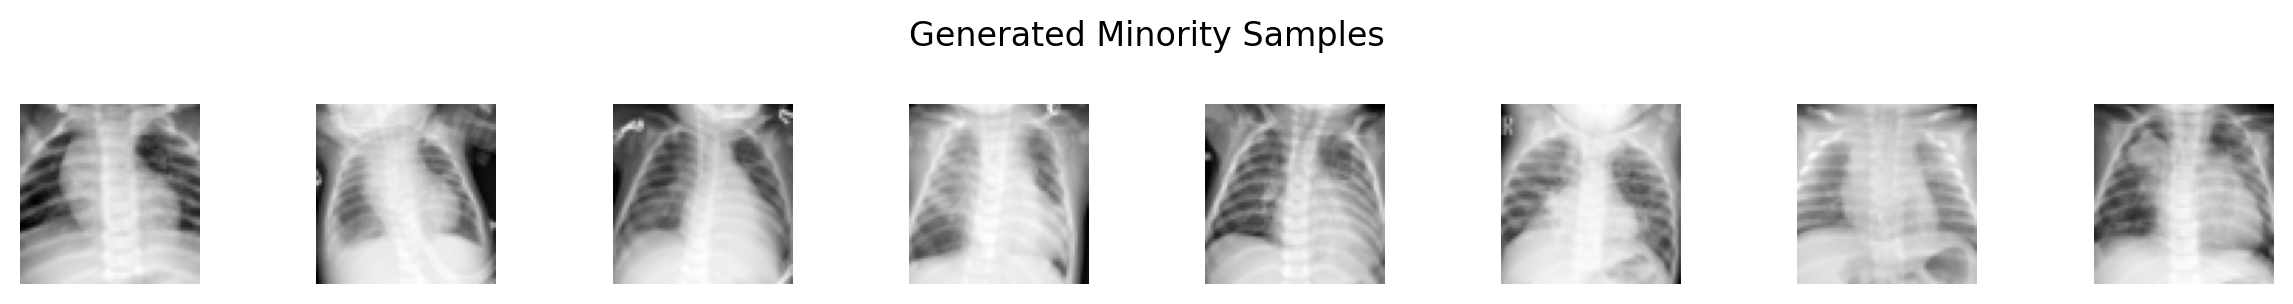

In [13]:
reset_all_seeds(SEED + 100)

n_minority_current = int(train_counts_after[MINORITY_CLASS])
n_target = n_minority_current * TARGET_MINORITY_MULTIPLIER
n_to_generate = max(0, n_target - n_minority_current)

print(f"Current minority: {n_minority_current}, target: {n_target}, generating: {n_to_generate}")

if n_to_generate > 0:
    seed_idx = np.random.choice(len(minority_images), n_to_generate, replace=True)
    seed_imgs = minority_images[seed_idx]
    generated_images = generate_inpainted_samples(
        denoiser,
        seed_imgs,
        n_per_image=1,
        mask_frac=INPAINT_MASK_FRAC,
    ).numpy().astype(np.float32)
    generated_labels = np.full(len(generated_images), MINORITY_CLASS, dtype=np.int32)
    print(f"Generated {len(generated_images)} samples, shape: {generated_images.shape}")
    plot_image_grid(generated_images, n=8, title="Generated Minority Samples", save_name="generated_minority_samples.png")
else:
    generated_images = np.empty((0, IMG_SIZE, IMG_SIZE, 1), dtype=np.float32)
    generated_labels = np.array([], dtype=np.int32)
    print("No samples needed.")

## Train Diffusion Augmentation CNN

Training set = imbalanced real training data ∪ diffusion-generated minority samples. Validation and test data remain unchanged.

Diffusion-augmented train set: 2610 samples
Class counts: [1214 1396]

── Training Diffusion Aug CNN for 25 epochs ──
Epoch 1/25
78/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8730 - loss: 0.2933

2026-05-19 12:51:33.790964: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-19 12:51:33.790997: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-19 12:51:34.226378: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1244', 8 bytes spill stores, 8 bytes spill loads

2026-05-19 12:51:34.365479: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : R

82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.9111 - loss: 0.2233 - val_accuracy: 0.7424 - val_loss: 3.1187
Epoch 2/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9421 - loss: 0.1523 - val_accuracy: 0.7424 - val_loss: 5.1431
Epoch 3/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9659 - loss: 0.0976 - val_accuracy: 0.7424 - val_loss: 4.8747
Epoch 4/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9693 - loss: 0.0818 - val_accuracy: 0.7424 - val_loss: 3.9404
Epoch 5/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9701 - loss: 0.0837 - val_accuracy: 0.7424 - val_loss: 7.2267
Epoch 6/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9805 - loss: 0.0535 - val_accuracy: 0.7424 - val_loss: 3.4776
Epoch 7/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9793 - loss: 0.0545 - val_accuracy: 0.7557 - val_loss: 1.6830
Epoch 8/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0533 - val_accuracy: 0.8893 - val_loss: 0.3149
E

  ✓ Validated checkpoints/diffusion_aug_cnn_final.keras

  Diffusion Aug CNN — Test Evaluation
  Accuracy: 0.9103  Macro-F1: 0.8990
  Minority Precision: 0.8778  Minority Recall: 0.9949
              precision    recall  f1-score   support

      normal       0.99      0.77      0.87       234
   pneumonia       0.88      0.99      0.93       390

    accuracy                           0.91       624
   macro avg       0.93      0.88      0.90       624
weighted avg       0.92      0.91      0.91       624

Saved: checkpoints/visualizations/diffusion_aug_confusion_matrix.png


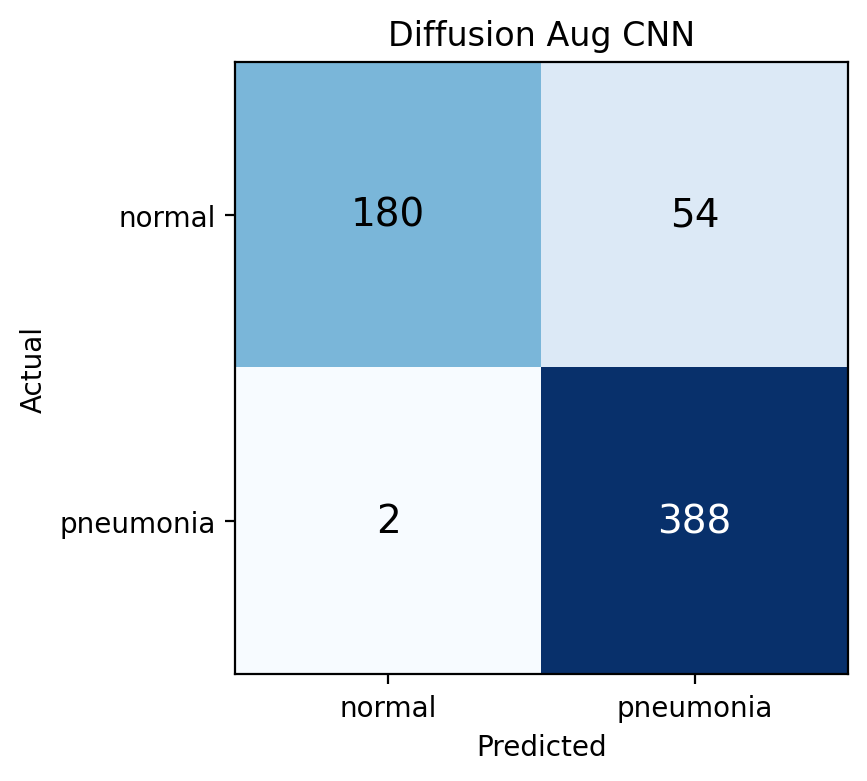

In [14]:
reset_all_seeds(SEED + 3000)

diff_train_images = np.concatenate([imb_train_images, generated_images], axis=0).astype(np.float32)
diff_train_labels = np.concatenate([imb_train_labels, generated_labels], axis=0).astype(np.int32)
perm = np.random.permutation(len(diff_train_images))
diff_train_images = diff_train_images[perm]
diff_train_labels = diff_train_labels[perm]
print(f"Diffusion-augmented train set: {len(diff_train_images)} samples")
print("Class counts:", np.bincount(diff_train_labels, minlength=2))

diff_train_ds = make_tf_dataset(diff_train_images, diff_train_labels)

diff_aug_cnn = build_cnn()
diff_aug_cnn, diff_history = train_classifier_fixed(
    diff_aug_cnn,
    diff_train_ds,
    val_ds,
    DIFFUSION_AUG_FINAL_PATH,
    "Diffusion Aug CNN",
    seed_offset=3000,
)

diff_metrics = evaluate_model(diff_aug_cnn, test_images, test_labels, "Diffusion Aug CNN")
plot_confusion_matrix(np.array(diff_metrics["confusion_matrix"]), "Diffusion Aug CNN", save_name="diffusion_aug_confusion_matrix.png")

## Save Metadata and Expected Metrics

In [15]:
import sklearn as _sk
import medmnist as _mm

metadata = {
    "design": "final-only 3-model checkpoint preparation",
    "seed": SEED,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "classifier_epochs": CLASSIFIER_EPOCHS,
    "classifier_model_selection": "fixed full training schedule; final epoch checkpoint; no early stopping",
    "label_map": label_map,
    "minority_class": MINORITY_CLASS,
    "minority_keep_fraction": MINORITY_KEEP_FRACTION,
    "target_minority_multiplier": TARGET_MINORITY_MULTIPLIER,
    "train_class_counts_before": train_counts_before.tolist(),
    "train_class_counts_after": train_counts_after.tolist(),
    "n_generated_minority_samples": int(len(generated_images)),
    "diffusion_augmented_train_class_counts": np.bincount(diff_train_labels, minlength=2).tolist(),
    "best_denoiser_epoch": BEST_DENOISER_EPOCH,
    "best_denoiser_source_path": BEST_DENOISER_PATH,
    "denoiser_final_path": DENOISER_FINAL_PATH,
    "baseline_final_path": BASELINE_FINAL_PATH,
    "traditional_aug_final_path": TRAD_AUG_FINAL_PATH,
    "diffusion_aug_final_path": DIFFUSION_AUG_FINAL_PATH,
    "diffusion_timesteps": DIFFUSION_TIMESTEPS,
    "noise_beta_start": NOISE_BETA_START,
    "noise_beta_end": NOISE_BETA_END,
    "inpaint_mask_frac": INPAINT_MASK_FRAC,
    "traditional_augmentation": {
        "random_rotation_factor": TRAD_ROTATION_FACTOR,
        "random_translation_factor": TRAD_TRANSLATION_FACTOR,
        "random_zoom_factor": TRAD_ZOOM_FACTOR,
        "random_contrast_factor": TRAD_CONTRAST_FACTOR,
        "horizontal_flip": False,
    },
    "data_rules": {
        "imbalance_applied_to": "train only",
        "generated_samples_added_to": "train only",
        "traditional_augmentation_applied_to": "train only",
        "validation_modified": False,
        "test_modified": False,
    },
    "package_versions": {
        "tensorflow": tf.__version__,
        "keras": keras.__version__,
        "sklearn": _sk.__version__,
        "medmnist": _mm.__version__,
        "numpy": np.__version__,
    },
}

with open(METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"Saved: {METADATA_PATH}")

expected = {
    "baseline": baseline_metrics,
    "traditional_aug": trad_metrics,
    "diffusion_aug": diff_metrics,
}
with open(EXPECTED_METRICS_PATH, "w") as f:
    json.dump(expected, f, indent=2)
print(f"Saved: {EXPECTED_METRICS_PATH}")

Saved: checkpoints/checkpoint_metadata.json
Saved: checkpoints/expected_metrics.json


## Final Checks

In [16]:
print("\n" + "=" * 60)
print("  CHECKPOINT VERIFICATION")
print("=" * 60)

all_paths = [
    (DENOISER_FINAL_PATH, True),
    (BASELINE_FINAL_PATH, False),
    (TRAD_AUG_FINAL_PATH, False),
    (DIFFUSION_AUG_FINAL_PATH, False),
]

for path, is_den in all_paths:
    exists = os.path.exists(path)
    size_kb = os.path.getsize(path) / 1024 if exists else 0
    print(f"  {'✓' if exists else '✗'} {path} ({size_kb:.0f} KB)")
    if exists:
        validate_checkpoint(path, is_denoiser=is_den)

print(f"\n  ✓ {METADATA_PATH}: exists={os.path.exists(METADATA_PATH)}")
print(f"  ✓ {EXPECTED_METRICS_PATH}: exists={os.path.exists(EXPECTED_METRICS_PATH)}")

print("\n" + "=" * 60)
print("  MODEL COMPARISON")
print("=" * 60)
print(f"  {'Model':<25} {'Acc':>8} {'F1':>8} {'Prec':>8} {'Rec':>8}")
print(f"  {'-' * 57}")
for name, metrics in [
    ("Baseline", baseline_metrics),
    ("Traditional Aug", trad_metrics),
    ("Diffusion Aug", diff_metrics),
]:
    print(
        f"  {name:<25} "
        f"{metrics['accuracy']:>8.4f} "
        f"{metrics['macro_f1']:>8.4f} "
        f"{metrics['minority_precision']:>8.4f} "
        f"{metrics['minority_recall']:>8.4f}"
    )

print("\n✅ Final-only 3-model checkpoint preparation complete.")


  CHECKPOINT VERIFICATION
  ✓ checkpoints/denoiser_final.keras (110925 KB)


  ✓ Loaded checkpoints/denoiser_final.keras
  ✓ Validated checkpoints/denoiser_final.keras
  ✓ checkpoints/baseline_cnn_final.keras (5022 KB)
  ✓ Loaded checkpoints/baseline_cnn_final.keras
  ✓ Validated checkpoints/baseline_cnn_final.keras
  ✓ checkpoints/traditional_aug_cnn_final.keras (5022 KB)
  ✓ Loaded checkpoints/traditional_aug_cnn_final.keras
  ✓ Validated checkpoints/traditional_aug_cnn_final.keras
  ✓ checkpoints/diffusion_aug_cnn_final.keras (5022 KB)
  ✓ Loaded checkpoints/diffusion_aug_cnn_final.keras
  ✓ Validated checkpoints/diffusion_aug_cnn_final.keras

  ✓ checkpoints/checkpoint_metadata.json: exists=True
  ✓ checkpoints/expected_metrics.json: exists=True

  MODEL COMPARISON
  Model                          Acc       F1     Prec      Rec
  ---------------------------------------------------------
  Baseline                    0.7356   0.6404   0.7027   1.0000
  Traditional Aug             0.7356   0.7308   0.8549   0.6949
  Diffusion Aug               0.9103   0.8990